In [48]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from rfdetr import RFDETRBase
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json

# 1. LOAD BOTH MODELS

In [ ]:
print("=" * 60)
print("LOADING MODELS")
print("=" * 60)

# Baseline model (without CKA loss)
model_baseline = RFDETRBase(
    pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\checkpoint_best_total.pth"
)
print("✓ Baseline model loaded from: trained_models")

# CKA loss model
model_cka = RFDETRBase(
    pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\checkpoint_best_total.pth"
)
print("✓ CKA model loaded from: aquatic_multilayer_output")

LOADING MODELS
Loading pretrain weights
✓ Baseline model loaded from: basketball_output
Loading pretrain weights
✓ CKA model loaded from: basketball_multiplayer_output


# 2. LOAD TEST DATASET

In [ ]:
DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

print(f"\n✓ Test dataset loaded: {len(ds)} images")
print("=" * 60)


✓ Test dataset loaded: 169 images


# 3. RUN INFERENCE ON BOTH MODELS

In [ ]:
def run_inference(model, dataset, model_name):
    """Run inference and collect predictions"""
    targets = []
    predictions = []
    
    print(f"\nRunning inference with {model_name}...")
    for path, image, annotations in tqdm(ds, desc=model_name):
        image = Image.open(path)
        detections = model.predict(image, threshold=0)
        
        targets.append(annotations)
        predictions.append(detections)
    
    return targets, predictions

# Run inference for baseline
targets_baseline, predictions_baseline = run_inference(model_baseline, ds, "Baseline Model")

# Run inference for CKA (reuse targets, same dataset)
_, predictions_cka = run_inference(model_cka, ds, "CKA Model")


Running inference with Baseline Model...


Baseline Model: 100%|██████████| 169/169 [00:50<00:00,  3.32it/s]



Running inference with CKA Model...


CKA Model: 100%|██████████| 169/169 [00:30<00:00,  5.59it/s]


# 4. CALCULATE METRICS FOR BOTH MODELS

In [52]:
print("\n" + "=" * 60)
print("CALCULATING METRICS")
print("=" * 60)

# Baseline metrics
map_baseline = MeanAveragePrecision()
map_baseline.update(predictions_baseline, targets_baseline)
results_baseline = map_baseline.compute()




print("\n✅ Baseline Model Results:")
print(f"  mAP@0.5:0.95: {results_baseline.map50_95:.4f}")
print(f"  mAP@0.5:      {results_baseline.map50:.4f}")
print(f"  mAP@0.75:     {results_baseline.map75:.4f}")

# CKA metrics
map_cka = MeanAveragePrecision()
map_cka.update(predictions_cka, targets_baseline)
results_cka = map_cka.compute()

print("\n✅ CKA Model Results:")
print(f"  mAP@0.5:0.95: {results_cka.map50_95:.4f}")
print(f"  mAP@0.5:      {results_cka.map50:.4f}")
print(f"  mAP@0.75:     {results_cka.map75:.4f}")


CALCULATING METRICS

✅ Baseline Model Results:
  mAP@0.5:0.95: 0.5744
  mAP@0.5:      0.9274
  mAP@0.75:     0.5995

✅ CKA Model Results:
  mAP@0.5:0.95: 0.5801
  mAP@0.5:      0.9280
  mAP@0.75:     0.6083


# 5. COMPARE METRICS

In [53]:
print("\n" + "=" * 60)
print("COMPARISON (CKA vs Baseline)")
print("=" * 60)

improvement50_95 = results_cka.map50_95 - results_baseline.map50_95
improvement50 = results_cka.map50 - results_baseline.map50
improvement75 = results_cka.map75 - results_baseline.map75

print(f"mAP@0.5:0.95 improvement: {improvement50_95:+.4f} ({(improvement50_95/results_baseline.map50_95)*100:+.2f}%)")
print(f"mAP@0.5 improvement:      {improvement50:+.4f} ({(improvement50/results_baseline.map50)*100:+.2f}%)")
print(f"mAP@0.75 improvement:     {improvement75:+.4f} ({(improvement75/results_baseline.map75)*100:+.2f}%)")


COMPARISON (CKA vs Baseline)
mAP@0.5:0.95 improvement: +0.0057 (+0.99%)
mAP@0.5 improvement:      +0.0006 (+0.06%)
mAP@0.75 improvement:     +0.0087 (+1.46%)


# 6. CREATE COMPARISON TABLE

In [54]:
comparison_df = pd.DataFrame({
    'Metric': ['mAP@0.5:0.95', 'mAP@0.5', 'mAP@0.75'],
    'Baseline': [results_baseline.map50_95, results_baseline.map50, results_baseline.map75],
    'CKA Model': [results_cka.map50_95, results_cka.map50, results_cka.map75],
    'Improvement': [improvement50_95, improvement50, improvement75],
    'Improvement (%)': [
        (improvement50_95/results_baseline.map50_95)*100,
        (improvement50/results_baseline.map50)*100,
        (improvement75/results_baseline.map75)*100
    ]
})

print("\n" + "=" * 60)
print("DETAILED COMPARISON TABLE")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv('model_comparison.csv', index=False)
print("\n✓ Comparison saved to: model_comparison.csv")


DETAILED COMPARISON TABLE
      Metric  Baseline  CKA Model  Improvement  Improvement (%)
mAP@0.5:0.95  0.574425   0.580134     0.005709         0.993822
     mAP@0.5  0.927440   0.928040     0.000600         0.064665
    mAP@0.75  0.599533   0.608279     0.008746         1.458834

✓ Comparison saved to: model_comparison.csv


# 7. VISUALIZE COMPARISON

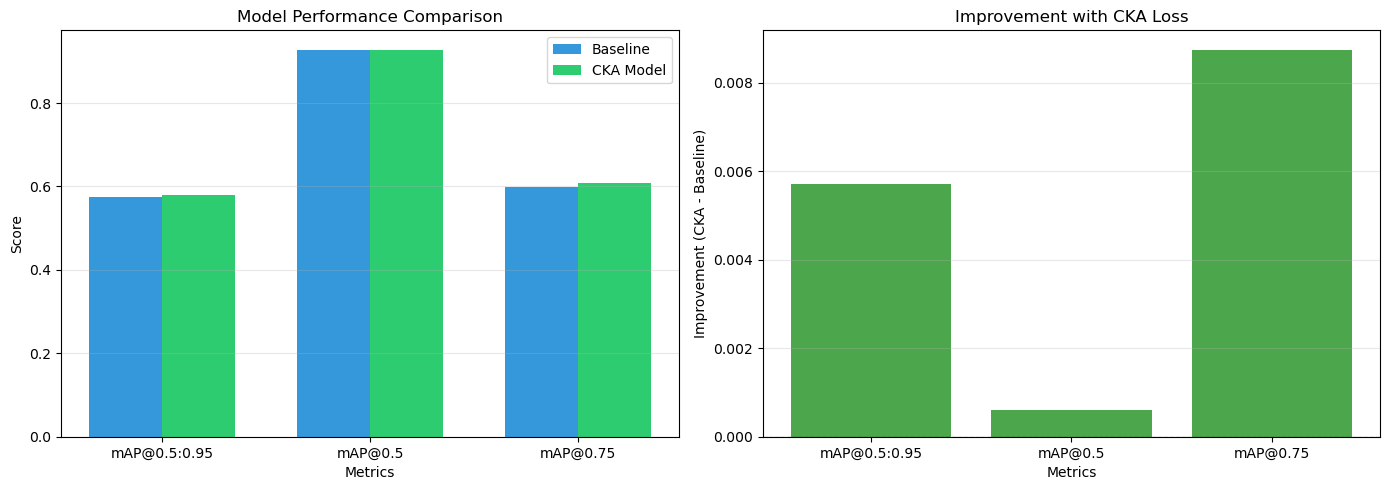


✓ Visualization saved to: model_comparison.png


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparison
metrics = ['mAP@0.5:0.95', 'mAP@0.5', 'mAP@0.75']
baseline_scores = [results_baseline.map50_95, results_baseline.map50, results_baseline.map75]
cka_scores = [results_cka.map50_95, results_cka.map50, results_cka.map75]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, baseline_scores, width, label='Baseline', color='#3498db')
axes[0].bar(x + width/2, cka_scores, width, label='CKA Model', color='#2ecc71')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Improvement visualization
improvements = [improvement50_95, improvement50, improvement75]
colors = ['green' if x > 0 else 'red' for x in improvements]
axes[1].bar(metrics, improvements, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Improvement (CKA - Baseline)')
axes[1].set_title('Improvement with CKA Loss')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: model_comparison.png")

# 8. PER-CLASS PERFORMANCE (if available)

In [34]:
if hasattr(results_baseline, 'per_class'):
    print("\n" + "=" * 60)
    print("PER-CLASS COMPARISON")
    print("=" * 60)
    
    class_names = ds.classes
    
    for cls_name in class_names:
        baseline_cls = results_baseline.per_class.get(cls_name, {})
        cka_cls = results_cka.per_class.get(cls_name, {})
        
        print(f"\n{cls_name}:")
        print(f"  Baseline: mAP={baseline_cls.get('map', 0):.4f}")
        print(f"  CKA:      mAP={cka_cls.get('map', 0):.4f}")
        print(f"  Improvement: {(cka_cls.get('map', 0) - baseline_cls.get('map', 0)):+.4f}")


# 9. STATISTICAL SIGNIFICANCE (Optional)

In [35]:
from scipy import stats

def calculate_per_image_ap(predictions, targets):
    """Calculate AP for each image"""
    aps = []
    for pred, target in zip(predictions, targets):
        if len(target) > 0 and len(pred) > 0:
            # Simple IoU-based AP calculation per image
            # This is a simplified version; adjust as needed
            aps.append(len(pred.class_id) / len(target.class_id))
        else:
            aps.append(0.0)
    return np.array(aps)

baseline_aps = calculate_per_image_ap(predictions_baseline, targets_baseline)
cka_aps = calculate_per_image_ap(predictions_cka, targets_baseline)

# Paired t-test
t_stat, p_value = stats.ttest_rel(cka_aps, baseline_aps)

print("\n" + "=" * 60)
print("STATISTICAL SIGNIFICANCE TEST")
print("=" * 60)
print(f"Paired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ✅ Statistically significant (p < 0.05)")
else:
    print(f"  ⚠️ Not statistically significant (p >= 0.05)")

print("\n" + "=" * 60)
print("COMPARISON COMPLETE!")
print("=" * 60)


STATISTICAL SIGNIFICANCE TEST
Paired t-test:
  t-statistic: nan
  p-value: nan
  ⚠️ Not statistically significant (p >= 0.05)

COMPARISON COMPLETE!


# 10.  PARSE LOG FILES

In [36]:
def load_training_logs(output_dir):
    """
    Load training logs from output directory.
    RF-DETR typically saves logs in:
    - training_log.json
    - tensorboard events
    - or training history files
    """
    
    # Try to find training log file
    possible_files = [
        'training_log.json',
        'log.txt',
        'train_log.json',
        'history.json',
        'metrics.json'
    ]
    
    for filename in possible_files:
        filepath = os.path.join(output_dir, filename)
        if os.path.exists(filepath):
            print(f"✓ Found log file: {filename}")
            
            # Load JSON file
            if filename.endswith('.json'):
                with open(filepath, 'r') as f:
                    return json.load(f)
            
            # Load text file (parse if needed)
            elif filename.endswith('.txt'):
                with open(filepath, 'r') as f:
                    lines = f.readlines()
                    # Parse text logs (customize based on format)
                    return parse_logs(lines)
    
    print(f"⚠️ No training log found in {output_dir}")
    return None

def parse_logs(log_file_path):
    """Parse JSON log file (one JSON object per line)"""
    epochs = []
    train_loss = []
    train_loss_ce = []
    train_loss_bbox = []
    train_loss_giou = []
    test_loss = []
    test_loss_ce = []
    test_coco_map = []  # mAP@0.5:0.95
    test_coco_map50 = []  # mAP@0.5
    ema_test_coco_map = []
    ema_test_coco_map50 = []
    
    with open(log_file_path, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                
                epochs.append(data.get('epoch', 0))
                train_loss.append(data.get('train_loss', 0))
                train_loss_ce.append(data.get('train_loss_ce_unscaled', 0))
                train_loss_bbox.append(data.get('train_loss_bbox_unscaled', 0))
                train_loss_giou.append(data.get('train_loss_giou_unscaled', 0))
                
                test_loss.append(data.get('test_loss', 0))
                test_loss_ce.append(data.get('test_loss_ce_unscaled', 0))
                
                # Extract mAP from test_coco_eval_bbox (first element is mAP@0.5:0.95)
                test_coco = data.get('test_coco_eval_bbox', [0, 0])
                test_coco_map.append(test_coco[0] if len(test_coco) > 0 else 0)
                test_coco_map50.append(test_coco[1] if len(test_coco) > 1 else 0)
                
                # EMA metrics
                ema_test_coco = data.get('ema_test_coco_eval_bbox', [0, 0])
                ema_test_coco_map.append(ema_test_coco[0] if len(ema_test_coco) > 0 else 0)
                ema_test_coco_map50.append(ema_test_coco[1] if len(ema_test_coco) > 1 else 0)
                
            except json.JSONDecodeError:
                continue
    
    return {
        'epochs': epochs,
        'train_loss': train_loss,
        'train_loss_ce': train_loss_ce,
        'train_loss_bbox': train_loss_bbox,
        'train_loss_giou': train_loss_giou,
        'test_loss': test_loss,
        'test_loss_ce': test_loss_ce,
        'test_coco_map': test_coco_map,
        'test_coco_map50': test_coco_map50,
        'ema_test_coco_map': ema_test_coco_map,
        'ema_test_coco_map50': ema_test_coco_map50
    }


# 11. LOAD DATA FROM BOTH MODELS

In [ ]:
baseline_log = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\log.txt"
cka_log = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"

In [38]:
print("=" * 60)
print("LOADING TRAINING LOGS")
print("=" * 60)

baseline_data = parse_logs(baseline_log)
print(f"✓ Baseline: {len(baseline_data['epochs'])} epochs loaded")

cka_data = parse_logs(cka_log)
print(f"✓ CKA Model: {len(cka_data['epochs'])} epochs loaded")


LOADING TRAINING LOGS
✓ Baseline: 66 epochs loaded
✓ CKA Model: 50 epochs loaded


# 12. COMPREHENSIVE COMPARISON PLOTS

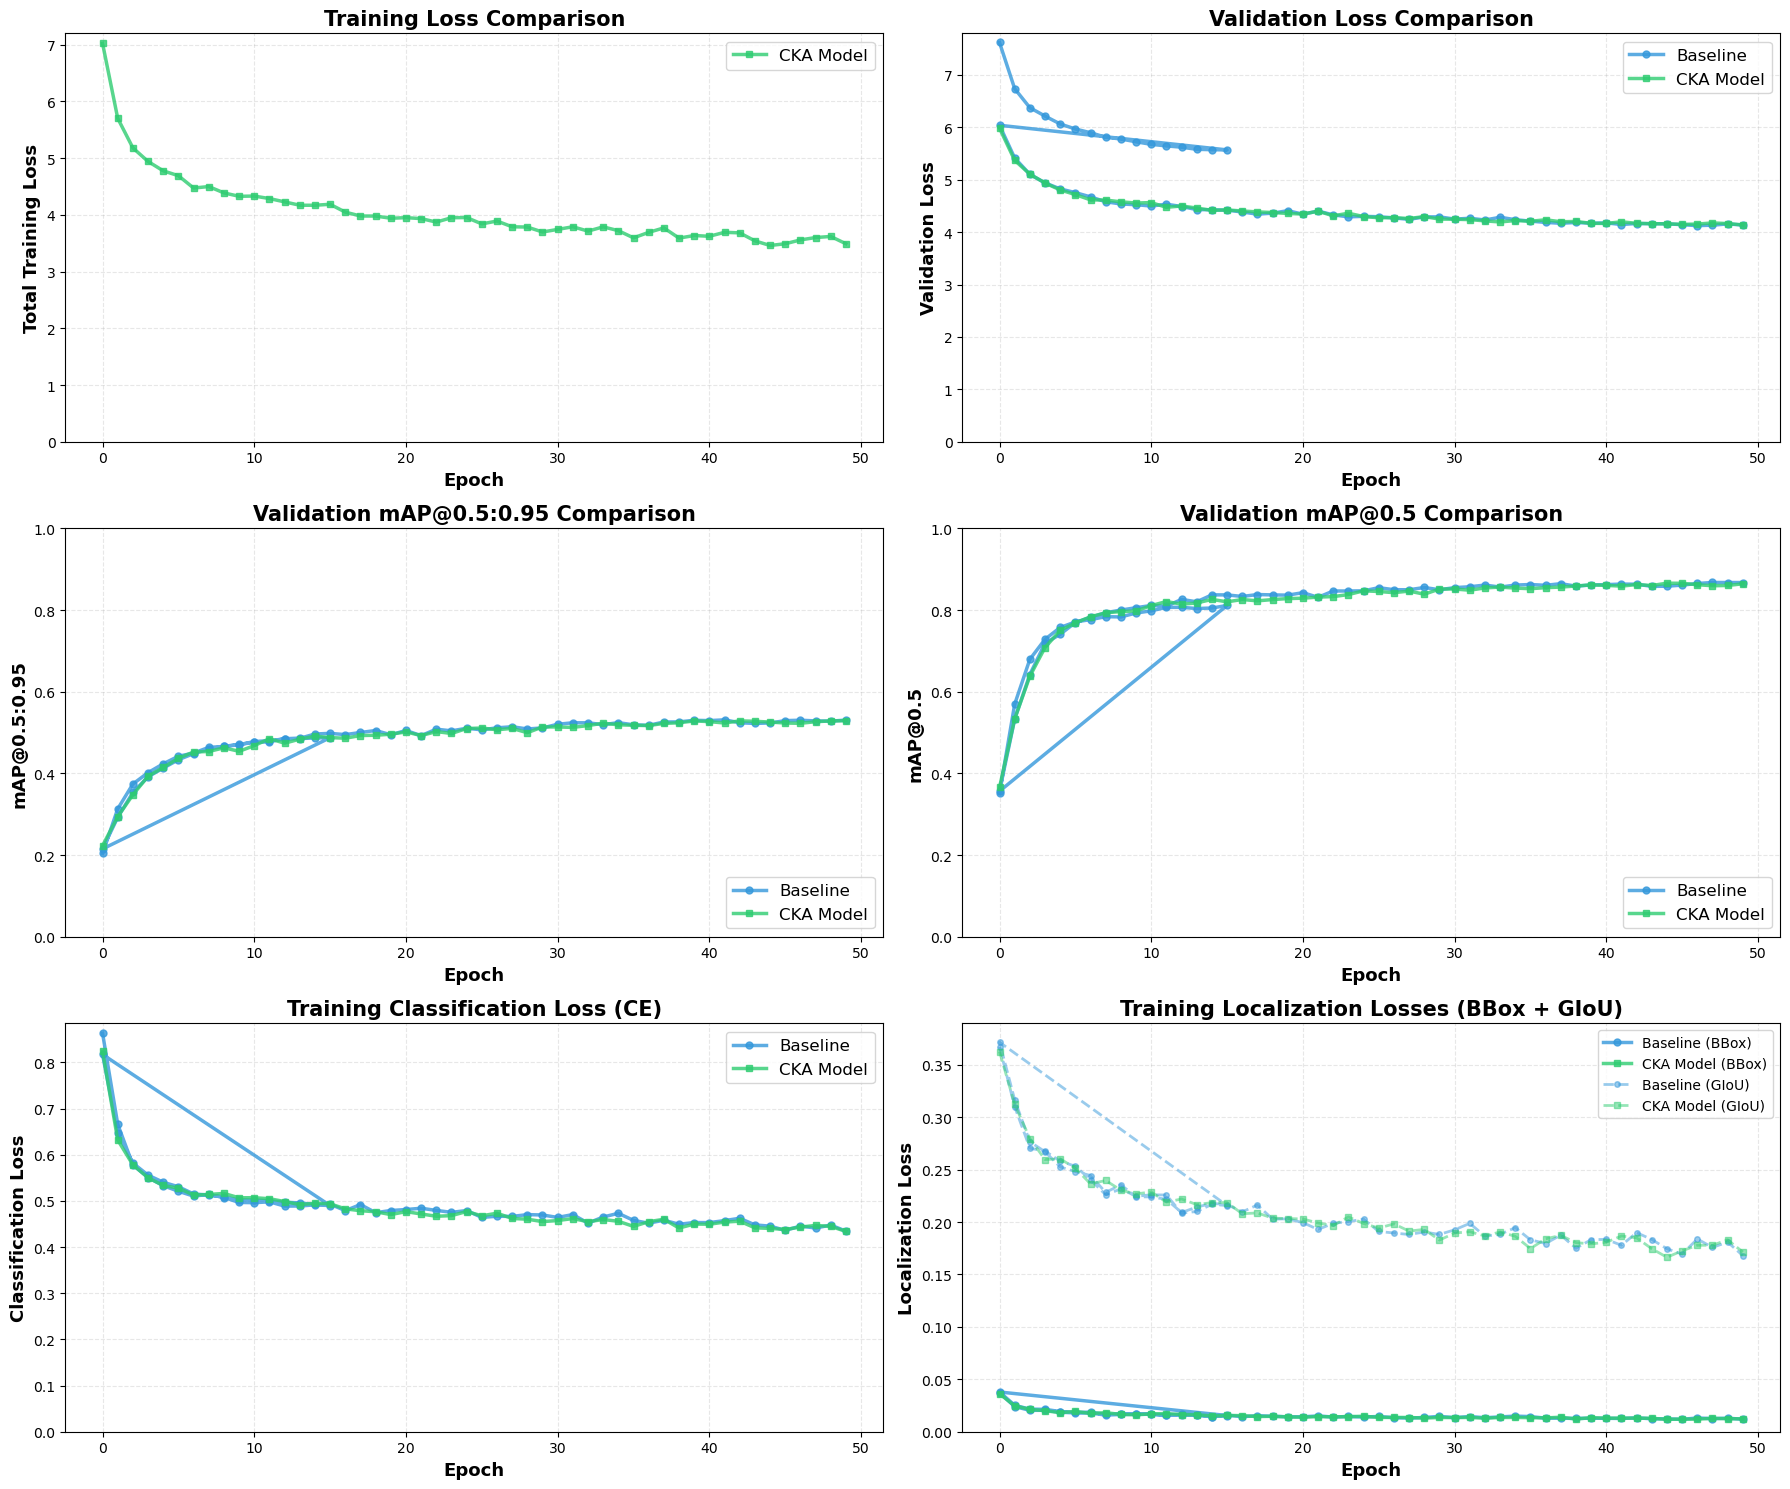


✓ Detailed training curves saved to: training_curves_detailed_comparison.png


In [39]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# Plot 1: Total Training Loss
ax1 = axes[0, 0]
# ax1.plot(baseline_data['epochs'], baseline_data['train_loss'], 
#          label='Baseline', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax1.plot(cka_data['epochs'], cka_data['train_loss'], 
         label='CKA Model', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Training Loss', fontsize=13, fontweight='bold')
ax1.set_title('Training Loss Comparison', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(bottom=0)

# Plot 2: Validation/Test Loss
ax2 = axes[0, 1]
ax2.plot(baseline_data['epochs'], baseline_data['test_loss'], 
         label='Baseline', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax2.plot(cka_data['epochs'], cka_data['test_loss'], 
         label='CKA Model', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Validation Loss', fontsize=13, fontweight='bold')
ax2.set_title('Validation Loss Comparison', fontsize=15, fontweight='bold')
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(bottom=0)

# Plot 3: mAP@0.5:0.95 (Most Important)
ax3 = axes[1, 0]
ax3.plot(baseline_data['epochs'], baseline_data['test_coco_map'], 
         label='Baseline', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax3.plot(cka_data['epochs'], cka_data['test_coco_map'], 
         label='CKA Model', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax3.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax3.set_ylabel('mAP@0.5:0.95', fontsize=13, fontweight='bold')
ax3.set_title('Validation mAP@0.5:0.95 Comparison', fontsize=15, fontweight='bold')
ax3.legend(fontsize=12, loc='lower right')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim(0, 1)

# Plot 4: mAP@0.5
ax4 = axes[1, 1]
ax4.plot(baseline_data['epochs'], baseline_data['test_coco_map50'], 
         label='Baseline', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax4.plot(cka_data['epochs'], cka_data['test_coco_map50'], 
         label='CKA Model', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax4.set_ylabel('mAP@0.5', fontsize=13, fontweight='bold')
ax4.set_title('Validation mAP@0.5 Comparison', fontsize=15, fontweight='bold')
ax4.legend(fontsize=12, loc='lower right')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim(0, 1)

# Plot 5: Classification Loss
ax5 = axes[2, 0]
ax5.plot(baseline_data['epochs'], baseline_data['train_loss_ce'], 
         label='Baseline', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax5.plot(cka_data['epochs'], cka_data['train_loss_ce'], 
         label='CKA Model', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax5.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax5.set_ylabel('Classification Loss', fontsize=13, fontweight='bold')
ax5.set_title('Training Classification Loss (CE)', fontsize=15, fontweight='bold')
ax5.legend(fontsize=12, loc='upper right')
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim(bottom=0)

# Plot 6: Bbox Localization Loss
ax6 = axes[2, 1]
ax6.plot(baseline_data['epochs'], baseline_data['train_loss_bbox'], 
         label='Baseline (BBox)', color='#3498db', linewidth=2.5, marker='o', markersize=5, alpha=0.8)
ax6.plot(cka_data['epochs'], cka_data['train_loss_bbox'], 
         label='CKA Model (BBox)', color='#2ecc71', linewidth=2.5, marker='s', markersize=5, alpha=0.8)
ax6.plot(baseline_data['epochs'], baseline_data['train_loss_giou'], 
         label='Baseline (GIoU)', color='#3498db', linewidth=2, marker='o', markersize=4, alpha=0.5, linestyle='--')
ax6.plot(cka_data['epochs'], cka_data['train_loss_giou'], 
         label='CKA Model (GIoU)', color='#2ecc71', linewidth=2, marker='s', markersize=4, alpha=0.5, linestyle='--')
ax6.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax6.set_ylabel('Localization Loss', fontsize=13, fontweight='bold')
ax6.set_title('Training Localization Losses (BBox + GIoU)', fontsize=15, fontweight='bold')
ax6.legend(fontsize=10, loc='upper right')
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('training_curves_detailed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Detailed training curves saved to: training_curves_detailed_comparison.png")


In [40]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print("\n📊 Final Training Loss (Last Epoch):")
print(f"  Baseline:  {baseline_data['train_loss'][-1]:.4f}")
print(f"  CKA Model: {cka_data['train_loss'][-1]:.4f}")
print(f"  Difference: {cka_data['train_loss'][-1] - baseline_data['train_loss'][-1]:+.4f}")

print("\n📊 Best Validation Loss:")
baseline_best_loss = min(baseline_data['test_loss'])
cka_best_loss = min(cka_data['test_loss'])
baseline_best_loss_epoch = baseline_data['test_loss'].index(baseline_best_loss)
cka_best_loss_epoch = cka_data['test_loss'].index(cka_best_loss)
print(f"  Baseline:  {baseline_best_loss:.4f} (Epoch {baseline_best_loss_epoch})")
print(f"  CKA Model: {cka_best_loss:.4f} (Epoch {cka_best_loss_epoch})")
print(f"  Improvement: {baseline_best_loss - cka_best_loss:+.4f}")

print("\n📊 Best Validation mAP@0.5:0.95:")
baseline_best_map = max(baseline_data['test_coco_map'])
cka_best_map = max(cka_data['test_coco_map'])
baseline_best_map_epoch = baseline_data['test_coco_map'].index(baseline_best_map)
cka_best_map_epoch = cka_data['test_coco_map'].index(cka_best_map)
print(f"  Baseline:  {baseline_best_map:.4f} (Epoch {baseline_best_map_epoch})")
print(f"  CKA Model: {cka_best_map:.4f} (Epoch {cka_best_map_epoch})")
print(f"  Improvement: {cka_best_map - baseline_best_map:+.4f} ({((cka_best_map - baseline_best_map) / baseline_best_map * 100):+.2f}%)")

print("\n📊 Best Validation mAP@0.5:")
baseline_best_map50 = max(baseline_data['test_coco_map50'])
cka_best_map50 = max(cka_data['test_coco_map50'])
baseline_best_map50_epoch = baseline_data['test_coco_map50'].index(baseline_best_map50)
cka_best_map50_epoch = cka_data['test_coco_map50'].index(cka_best_map50)
print(f"  Baseline:  {baseline_best_map50:.4f} (Epoch {baseline_best_map50_epoch})")
print(f"  CKA Model: {cka_best_map50:.4f} (Epoch {cka_best_map50_epoch})")
print(f"  Improvement: {cka_best_map50 - baseline_best_map50:+.4f} ({((cka_best_map50 - baseline_best_map50) / baseline_best_map50 * 100):+.2f}%)")



TRAINING SUMMARY

📊 Final Training Loss (Last Epoch):
  Baseline:  3.4327
  CKA Model: 3.4909
  Difference: +0.0582

📊 Best Validation Loss:
  Baseline:  4.1240 (Epoch 62)
  CKA Model: 4.1377 (Epoch 49)
  Improvement: -0.0137

📊 Best Validation mAP@0.5:0.95:
  Baseline:  0.5311 (Epoch 57)
  CKA Model: 0.5288 (Epoch 49)
  Improvement: -0.0024 (-0.44%)

📊 Best Validation mAP@0.5:
  Baseline:  0.8674 (Epoch 63)
  CKA Model: 0.8657 (Epoch 44)
  Improvement: -0.0017 (-0.20%)


In [41]:
print("\n" + "=" * 60)
print("CONVERGENCE ANALYSIS")
print("=" * 60)

# Find epoch where each model reached 90% of best mAP
baseline_90_target = 0.9 * baseline_best_map
cka_90_target = 0.9 * cka_best_map

baseline_90_epoch = next((i for i, x in enumerate(baseline_data['test_coco_map']) if x >= baseline_90_target), None)
cka_90_epoch = next((i for i, x in enumerate(cka_data['test_coco_map']) if x >= cka_90_target), None)

print(f"\n📈 Epochs to reach 90% of best mAP@0.5:0.95:")
print(f"  Baseline:  Epoch {baseline_90_epoch if baseline_90_epoch else 'N/A'}")
print(f"  CKA Model: Epoch {cka_90_epoch if cka_90_epoch else 'N/A'}")
if baseline_90_epoch and cka_90_epoch:
    print(f"  Difference: {cka_90_epoch - baseline_90_epoch:+d} epochs")
    if cka_90_epoch < baseline_90_epoch:
        print(f"  ✅ CKA Model converged {baseline_90_epoch - cka_90_epoch} epochs faster!")
    elif cka_90_epoch > baseline_90_epoch:
        print(f"  ⚠️ CKA Model converged {cka_90_epoch - baseline_90_epoch} epochs slower")



CONVERGENCE ANALYSIS

📈 Epochs to reach 90% of best mAP@0.5:0.95:
  Baseline:  Epoch 11
  CKA Model: Epoch 11
  Difference: +0 epochs


In [42]:
summary_df = pd.DataFrame({
    'Metric': [
        'Final Training Loss',
        'Best Validation Loss',
        'Best mAP@0.5:0.95',
        'Best mAP@0.5',
        'Convergence (90% best mAP) Epoch'
    ],
    'Baseline': [
        f"{baseline_data['train_loss'][-1]:.4f}",
        f"{baseline_best_loss:.4f}",
        f"{baseline_best_map:.4f}",
        f"{baseline_best_map50:.4f}",
        f"{baseline_90_epoch if baseline_90_epoch else 'N/A'}"
    ],
    'CKA Model': [
        f"{cka_data['train_loss'][-1]:.4f}",
        f"{cka_best_loss:.4f}",
        f"{cka_best_map:.4f}",
        f"{cka_best_map50:.4f}",
        f"{cka_90_epoch if cka_90_epoch else 'N/A'}"
    ],
    'Improvement': [
        f"{cka_data['train_loss'][-1] - baseline_data['train_loss'][-1]:+.4f}",
        f"{baseline_best_loss - cka_best_loss:+.4f}",
        f"{cka_best_map - baseline_best_map:+.4f}",
        f"{cka_best_map50 - baseline_best_map50:+.4f}",
        f"{(cka_90_epoch - baseline_90_epoch) if (baseline_90_epoch and cka_90_epoch) else 'N/A'}"
    ]
})

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(summary_df.to_string(index=False))

summary_df.to_csv('training_summary_comparison.csv', index=False)
print("\n✓ Summary table saved to: training_summary_comparison.csv")

print("\n" + "=" * 60)
print("✅ TRAINING CURVES COMPARISON COMPLETE!")
print("=" * 60)


SUMMARY TABLE
                          Metric Baseline CKA Model Improvement
             Final Training Loss   3.4327    3.4909     +0.0582
            Best Validation Loss   4.1240    4.1377     -0.0137
               Best mAP@0.5:0.95   0.5311    0.5288     -0.0024
                    Best mAP@0.5   0.8674    0.8657     -0.0017
Convergence (90% best mAP) Epoch       11        11           0

✓ Summary table saved to: training_summary_comparison.csv

✅ TRAINING CURVES COMPARISON COMPLETE!


In [ ]:
# ============================================================
# CHECK FOR CKA LOSS IN TRAINING LOGS
# ============================================================

import json

def check_cka_loss_in_logs(log_file_path):
    """Check if CKA loss is present in the log file"""
    
    print("=" * 60)
    print(f"Checking for CKA loss in: {log_file_path}")
    print("=" * 60)
    
    with open(log_file_path, 'r') as f:
        first_line = json.loads(f.readline().strip())
        
        # Print all keys to see what's available
        print("\nAvailable keys in log file:")
        print("-" * 60)
        
        # Group keys by category
        train_keys = [k for k in first_line.keys() if k.startswith('train_')]
        test_keys = [k for k in first_line.keys() if k.startswith('test_')]
        other_keys = [k for k in first_line.keys() if not k.startswith(('train_', 'test_'))]
        
        print("\nTraining keys:")
        for key in sorted(train_keys):
            print(f"  - {key}")
        
        print("\nTest/Validation keys:")
        for key in sorted(test_keys)[:10]:  # Show first 10
            print(f"  - {key}")
        
        print("\nOther keys:")
        for key in sorted(other_keys):
            print(f"  - {key}")
        
        # Check specifically for CKA loss
        cka_keys = [k for k in first_line.keys() if 'cka' in k.lower()]
        
        if cka_keys:
            print("\n" + "=" * 60)
            print("✅ CKA LOSS FOUND!")
            print("=" * 60)
            print("\nCKA-related keys:")
            for key in cka_keys:
                print(f"  - {key}: {first_line[key]}")
            return True, cka_keys
        else:
            print("\n" + "=" * 60)
            print("❌ NO CKA LOSS FOUND IN LOGS")
            print("=" * 60)
            print("\nPossible reasons:")
            print("  1. CKA loss was set to 0 (cka_lambda=0)")
            print("  2. CKA loss computation failed silently")
            print("  3. CKA loss not being logged to file")
            return False, []

# Check the CKA model log file
cka_log = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"
has_cka, cka_keys = check_cka_loss_in_logs(cka_log)


Checking for CKA loss in: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aicast_loss_output\log.txt

Available keys in log file:
------------------------------------------------------------

Training keys:
  - train_cardinality_error_0_unscaled
  - train_cardinality_error_1_unscaled
  - train_cardinality_error_enc_unscaled
  - train_cardinality_error_unscaled
  - train_class_error
  - train_class_error_unscaled
  - train_epoch_time
  - train_loss
  - train_loss_bbox
  - train_loss_bbox_0
  - train_loss_bbox_0_unscaled
  - train_loss_bbox_1
  - train_loss_bbox_1_unscaled
  - train_loss_bbox_enc
  - train_loss_bbox_enc_unscaled
  - train_loss_bbox_unscaled
  - train_loss_ce
  - train_loss_ce_0
  - train_loss_ce_0_unscaled
  - train_loss_ce_1
  - train_loss_ce_1_unscaled
  - train_loss_ce_enc
  - train_loss_ce_enc_unscaled
  - train_loss_ce_unscaled
  - train_loss_cka_unscaled
  - train_loss_giou
  - train_loss_giou_0
  - train_loss_giou_0_unscaled
  - train_loss_giou_1
  -


✅ Successfully extracted 61 CKA loss values


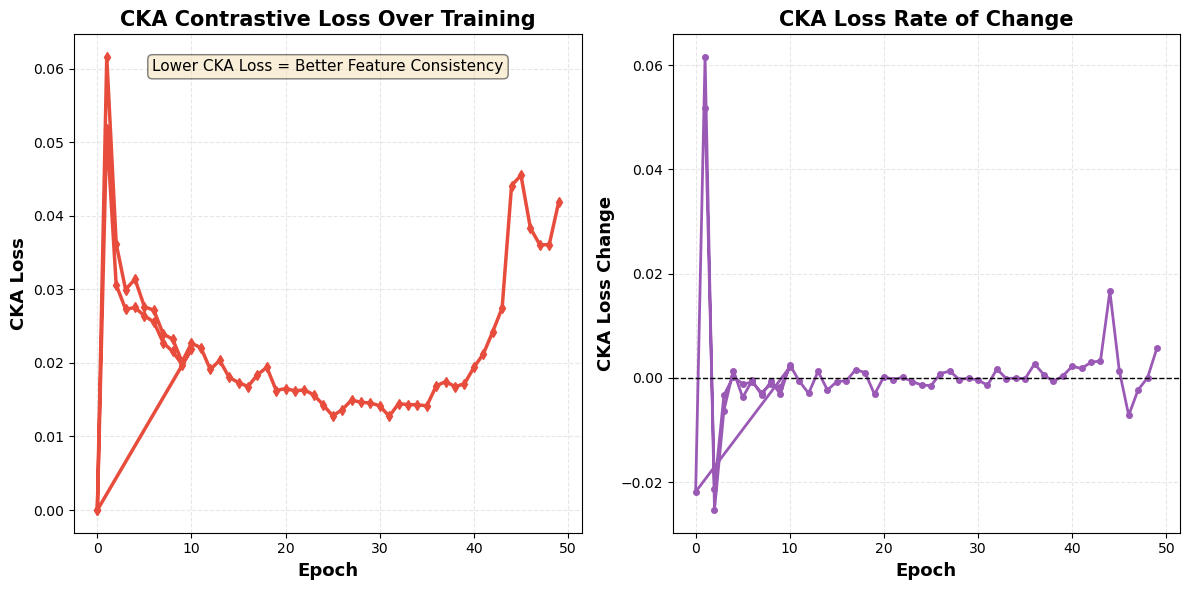

✓ CKA loss plot saved to: cka_loss_analysis.png

CKA LOSS STATISTICS
Initial CKA Loss (Epoch 0): 0.000000
Final CKA Loss (Epoch 49): 0.041798
Best (Minimum) CKA Loss: 0.000000 (Epoch 0)
Average CKA Loss: 0.022670


In [ ]:
# ============================================================
# EXTRACT AND PLOT CKA LOSS VALUES
# ============================================================

import matplotlib.pyplot as plt
import json

def extract_cka_loss(log_file_path, cka_key='train_loss_cka_unscaled'):
    """Extract CKA loss values from log file"""
    
    epochs = []
    cka_losses = []
    
    with open(log_file_path, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epoch = data.get('epoch', 0)
                
                # Try different possible CKA loss key names
                cka_loss = None
                for possible_key in ['train_loss_cka_unscaled', 'train_loss_cka', 
                                     'loss_cka', 'cka_loss', 'train_cka_loss']:
                    if possible_key in data:
                        cka_loss = data[possible_key]
                        break
                
                if cka_loss is not None:
                    epochs.append(epoch)
                    cka_losses.append(cka_loss)
                    
            except json.JSONDecodeError:
                continue
    
    return epochs, cka_losses

# Extract CKA loss
cka_log = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"
epochs, cka_losses = extract_cka_loss(cka_log)

if len(cka_losses) > 0:
    print(f"\n✅ Successfully extracted {len(cka_losses)} CKA loss values")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, cka_losses, color='#e74c3c', linewidth=2.5, marker='d', markersize=5)
    plt.xlabel('Epoch', fontsize=13, fontweight='bold')
    plt.ylabel('CKA Loss', fontsize=13, fontweight='bold')
    plt.title('CKA Contrastive Loss Over Training', fontsize=15, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add interpretation text
    plt.text(0.5, 0.95, 'Lower CKA Loss = Better Feature Consistency', 
             transform=plt.gca().transAxes, ha='center', va='top',
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Second plot: CKA Loss derivative (rate of change)
    plt.subplot(1, 2, 2)
    if len(cka_losses) > 1:
        cka_derivatives = [cka_losses[i] - cka_losses[i-1] for i in range(1, len(cka_losses))]
        plt.plot(epochs[1:], cka_derivatives, color='#9b59b6', linewidth=2, marker='o', markersize=4)
        plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
        plt.xlabel('Epoch', fontsize=13, fontweight='bold')
        plt.ylabel('CKA Loss Change', fontsize=13, fontweight='bold')
        plt.title('CKA Loss Rate of Change', fontsize=15, fontweight='bold')
        plt.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('cka_loss_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ CKA loss plot saved to: cka_loss_analysis.png")
    
    # Print statistics
    print("\n" + "=" * 60)
    print("CKA LOSS STATISTICS")
    print("=" * 60)
    print(f"Initial CKA Loss (Epoch 0): {cka_losses[0]:.6f}")
    print(f"Final CKA Loss (Epoch {epochs[-1]}): {cka_losses[-1]:.6f}")
    print(f"Best (Minimum) CKA Loss: {min(cka_losses):.6f} (Epoch {epochs[cka_losses.index(min(cka_losses))]})")
    print(f"Average CKA Loss: {sum(cka_losses)/len(cka_losses):.6f}")
    #print(f"Total Reduction: {cka_losses[0] - cka_losses[-1]:.6f} ({((cka_losses[0] - cka_losses[-1])/cka_losses[0]*100):.2f}%)")
    
else:
    print("\n❌ No CKA loss values found in the log file")


In [ ]:
# ============================================================
# DIAGNOSTIC: CHECK IF CKA LOSS WAS COMPUTED DURING TRAINING
# ============================================================

import json

def analyze_loss_components(log_file_path):
    """Analyze all loss components in the training log"""
    
    with open(log_file_path, 'r') as f:
        first_line = json.loads(f.readline().strip())
        last_line = None
        
        # Get last line
        f.seek(0)
        for line in f:
            last_line = json.loads(line.strip())
    
    print("=" * 60)
    print("LOSS COMPONENTS ANALYSIS")
    print("=" * 60)
    
    # Get all loss-related keys
    loss_keys = [k for k in first_line.keys() if 'loss' in k.lower() and 'unscaled' in k]
    
    print("\nFirst Epoch Loss Components:")
    for key in sorted(loss_keys):
        value = first_line.get(key, 0)
        print(f"  {key:40s} = {value:.6f}")
    
    print("\nLast Epoch Loss Components:")
    for key in sorted(loss_keys):
        value = last_line.get(key, 0)
        print(f"  {key:40s} = {value:.6f}")
    
    # Check for CKA specifically
    print("\n" + "-" * 60)
    if any('cka' in k.lower() for k in first_line.keys()):
        print("✅ CKA loss IS present in logs")
    else:
        print("❌ CKA loss NOT present in logs")
        print("\nThis could mean:")
        print("  1. cka_lambda was set to 0")
        print("  2. CKA loss computation is failing")
        print("  3. Loss is computed but not logged")

cka_log = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"
analyze_loss_components(cka_log)


LOSS COMPONENTS ANALYSIS

First Epoch Loss Components:
  ema_test_loss_bbox_0_unscaled            = 0.027483
  ema_test_loss_bbox_1_unscaled            = 0.026685
  ema_test_loss_bbox_enc_unscaled          = 0.027160
  ema_test_loss_bbox_unscaled              = 0.026316
  ema_test_loss_ce_0_unscaled              = 0.864373
  ema_test_loss_ce_1_unscaled              = 0.941269
  ema_test_loss_ce_enc_unscaled            = 0.827126
  ema_test_loss_ce_unscaled                = 0.899408
  ema_test_loss_giou_0_unscaled            = 0.374817
  ema_test_loss_giou_1_unscaled            = 0.368147
  ema_test_loss_giou_enc_unscaled          = 0.373612
  ema_test_loss_giou_unscaled              = 0.368902
  test_loss_bbox_0_unscaled                = 0.027324
  test_loss_bbox_1_unscaled                = 0.026563
  test_loss_bbox_enc_unscaled              = 0.027107
  test_loss_bbox_unscaled                  = 0.026011
  test_loss_ce_0_unscaled                  = 0.864748
  test_loss_ce_1_unscaled  

In [ ]:
import json

log_file = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"

with open(log_file, 'r') as f:
    first_epoch = json.loads(f.readline().strip())

print("Checking for CKA loss...")
print("-" * 60)

# Check all possible CKA key names
cka_candidates = ['train_loss_cka', 'train_loss_cka_unscaled', 'loss_cka', 
                  'cka_loss', 'train_cka', 'loss_cka_unscaled']

found = False
for key in cka_candidates:
    if key in first_epoch:
        print(f"✅ FOUND: {key} = {first_epoch[key]}")
        found = True

if not found:
    print("❌ CKA loss not found in log file")
    print("\nAll available keys:")
    for key in sorted(first_epoch.keys()):
        print(f"  - {key}")


Checking for CKA loss...
------------------------------------------------------------
✅ FOUND: train_loss_cka = 0.0
✅ FOUND: train_loss_cka_unscaled = 0.0
